# 1. Загрузка данных

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
url = "/content/drive/MyDrive/анализ продаж/data.csv"
data = pd.read_csv(url)

In [22]:
data.head(3)

,Invoice.ID,City,Customer.Type,Customer.Category,Gender,Product.Line,Advertising.Budget,Loyalty.Program,Discount.Rate,Payment,Total,Date
0,NSKELE9253,Novosibirsk,Normal,Student,Male,Electronics,15.43,Yes,27.52,Credit Card,156.39876,2024-06-28
1,SPBGRO7770,Saint Petersburg,Member,Working,Male,Groceries,NaN,Yes,8.11,Ewallet,299.94000,2024-03-17
2,MOWFUR4418,NaN,Member,Retired,Male,Furniture,19.87,Yes,8.13,Credit Card,281.93883,2024-01-09


# 2. Предварительная обработка данных

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Invoice.ID          764 non-null    object 
 1   City                771 non-null    object 
 2   Customer.Type       760 non-null    object 
 3   Customer.Category   756 non-null    object 
 4   Gender              761 non-null    object 
 5   Product.Line        749 non-null    object 
 6   Advertising.Budget  225 non-null    float64
 7   Loyalty.Program     761 non-null    object 
 8   Discount.Rate       758 non-null    float64
 9   Payment             773 non-null    object 
 10  Total               757 non-null    float64
 11  Date                757 non-null    object 
dtypes: float64(3), object(9)
memory usage: 75.1+ KB


In [24]:
clean_data = data.loc[(data['City'].notna()) & (data['Total'].notna()) & (data['Product.Line'].notna())].copy()
clean_data.drop(columns=['Invoice.ID', 'Date'], axis=0, inplace=True)
clean_advertising = clean_data.loc[clean_data['Advertising.Budget'].notna()].copy()

In [25]:
cat_cols = clean_data.select_dtypes(include="object").columns
cat_cols

Index(['City', 'Customer.Type', 'Customer.Category', 'Gender', 'Product.Line',
       'Loyalty.Program', 'Payment'],
      dtype='object')

# 3. Анализ данных

## 3.1. График распределения категориальных признаков

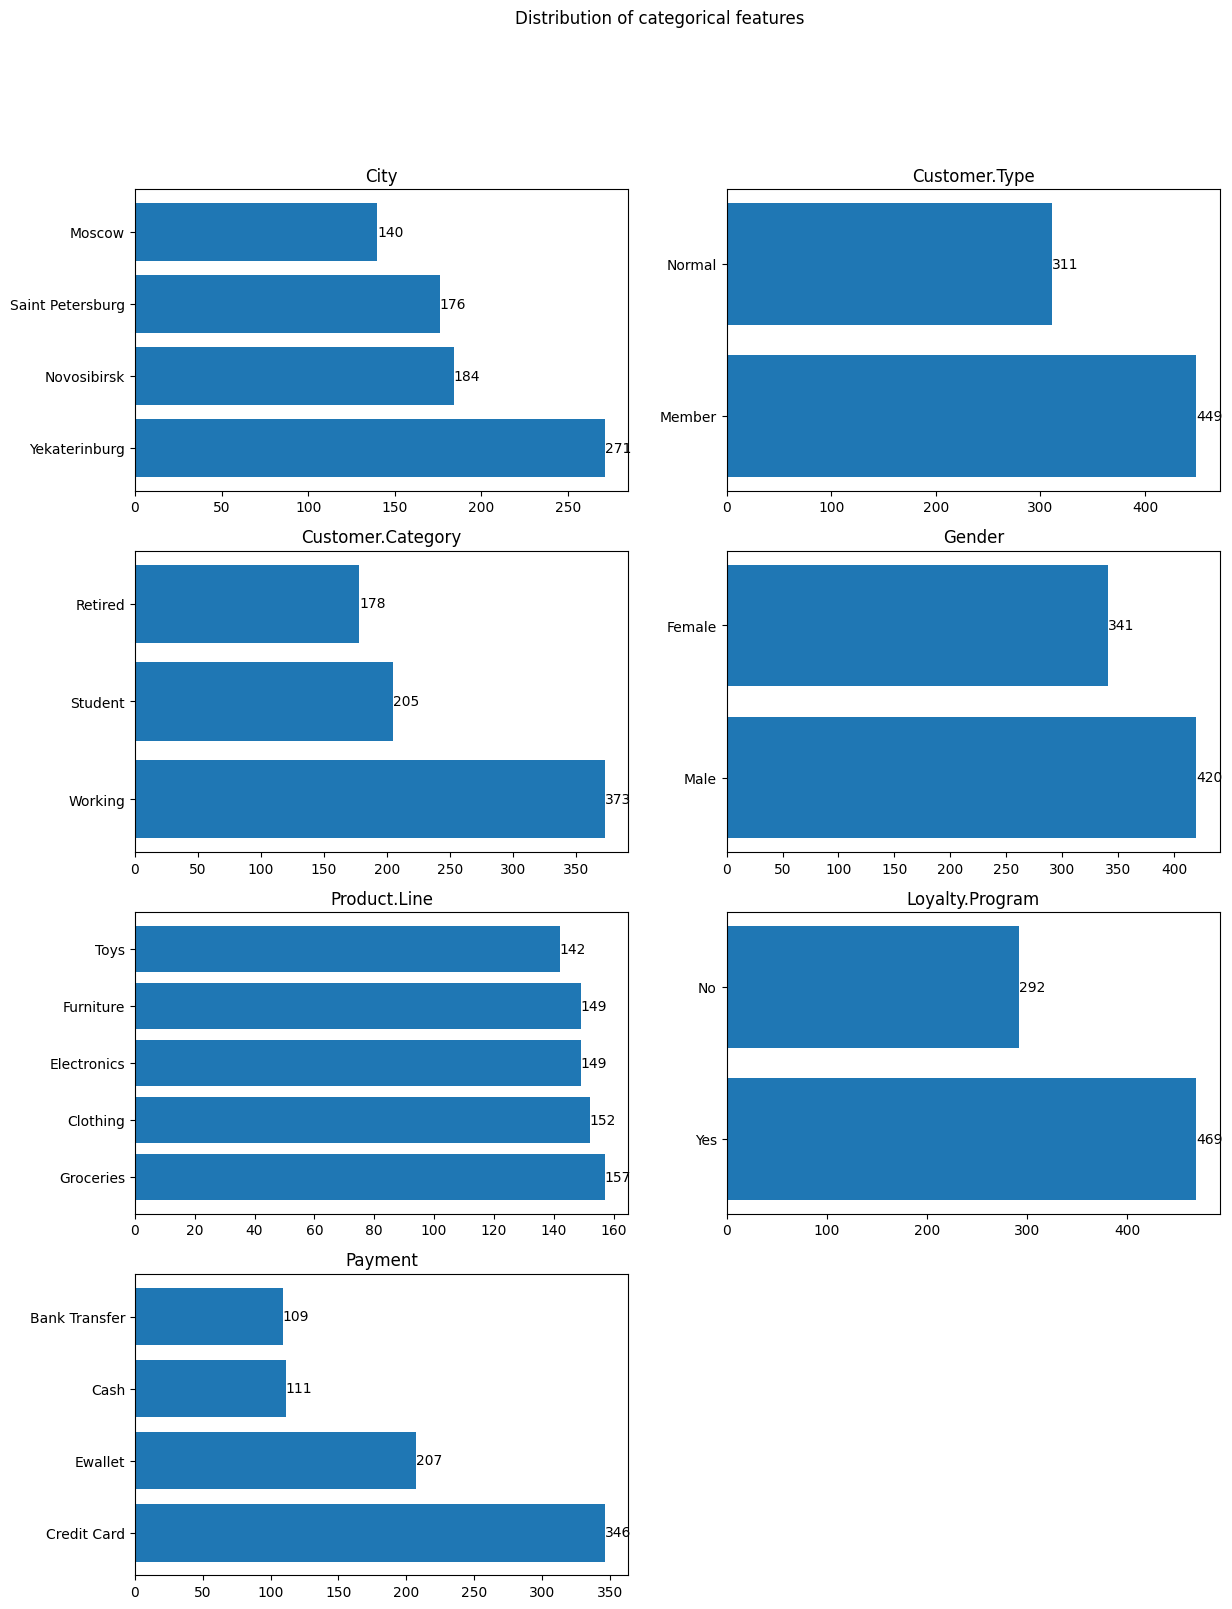

In [27]:
fig, axes = plt.subplots(ncols=2, nrows=4, figsize=(14,18))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

  counts = data[col].value_counts(dropna=True)

  bars = axes[i].barh(counts.index, counts.values)
  axes[i].set_title(col)
  axes[i].bar_label(bars)

fig.suptitle("Distribution of categorical features")

fig.delaxes(axes[7])

**Вывод**:

Чаще всего совершают покупки:
* в Екатеринбурге
* постоянные клиенты
* рабочий класс населения
* мужчины
* участники программы лояльности



## 3.2. Boxplot для суммы покупок по городам

Text(0.5, 1.0, 'Distribution of check amount by city')

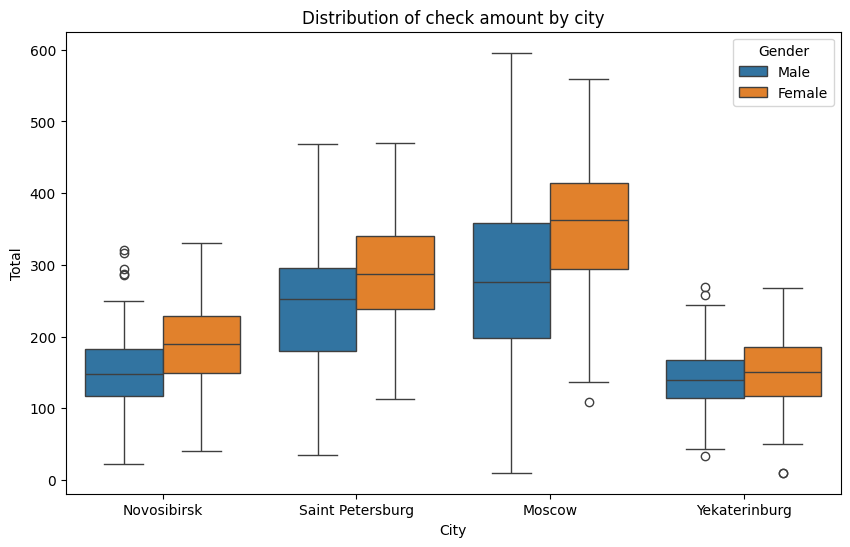

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(data=clean_data, x='City',y='Total',hue='Gender')

plt.title("Distribution of check amount by city")

**Вывод**:

*   у женщин в среднем чек больше, чем у мужчин
*   чек в Москве и Санкт-Петербурге больше, чем в Новосибирске и Екатеринбурге
*   в Москве и Санкт-Петербурге выше вариативность трат



## 3.3. Распределение суммы чека

Проверим на нормальность распределение суммы чека с помощью теста Шапироу-Уилка.

In [30]:
import scipy.stats as stats

stat, p_value = stats.shapiro(clean_data['Total'])

p_value.item()

1.9424439834953663e-15

В результате мы получили значение p_value < 0.05, что позволяет нам отклонить нулевую гипотезу о нормальности распределения.

Построим график, чтобы в этом убедиться.

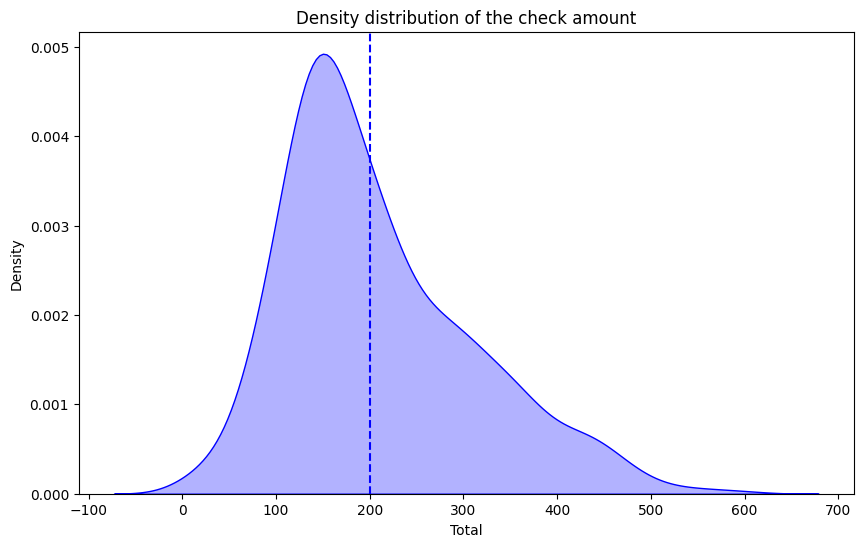

In [37]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=clean_data['Total'],
    label='Total',
    fill=True,
    color='blue',
    alpha=0.3
)

plt.title("Density distribution of the check amount")
plt.axvline(group_toys.mean(), color='blue', linestyle='--', label='Mean Total')

## 3.4. Сводная таблица

Построим сводную таблицу медианы суммы чека по городам и расходам на рекламу

Text(0.5, 1.0, 'Median check amount by city and advertising costs')

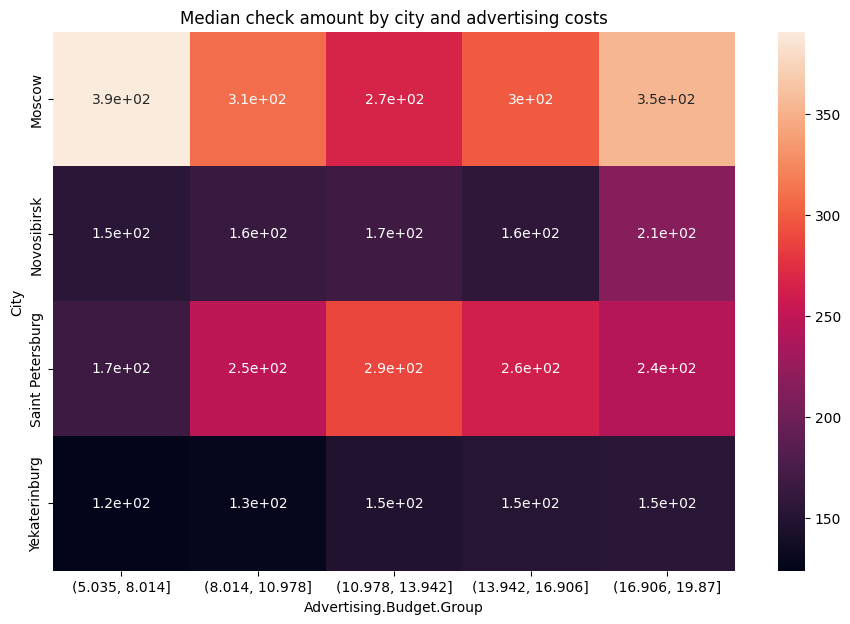

In [38]:
clean_advertising['Advertising.Budget.Group'] = pd.cut(clean_advertising['Advertising.Budget'], bins=5)

pivot_t = clean_advertising.pivot_table(
    values='Total',
    index='City',
    columns='Advertising.Budget.Group',
    aggfunc='median',
    observed=False
)

plt.figure(figsize=(11,7))
sns.heatmap(
    data=pivot_t,
    annot=True
)

plt.title('Median check amount by city and advertising costs')

**Вывод**:

в Москве и Санкт-Петербурге больший медианный чек достигается при меньших затратах на рекламу.

## 3.5. Проверка гипотезы о равенстве средних значений

Проверим гипотезу о равенстве средних значений продаж между категориями товаров Toys и Electronics с помощью t-теста Стьюдента и теста Манна-Уитни.

In [39]:
group_toys = clean_data.loc[(data['Product.Line'] == 'Toys'), 'Total']
group_electronics = clean_data.loc[(data['Product.Line'] == 'Electronics'), 'Total']

t_stat, p_value = stats.ttest_ind(group_toys, group_electronics)

p_value.item()

0.031999485713535426

In [40]:
t_stat, p_value = stats.mannwhitneyu(group_toys, group_electronics)

p_value.item()

0.08461094185424371

В нашем случае данные распределены не нормально, поэтому предпочтительно использовать тест Манна-Уитни, который показал значение p_value > 0.05, а значит нет достаточных оснований отклонять нулевую гипотезу о равенстве средних.

Построим графики плотности распределения обеих выборок.


Text(0.5, 1.0, 'Density distribution of the cost of toys and electronics')

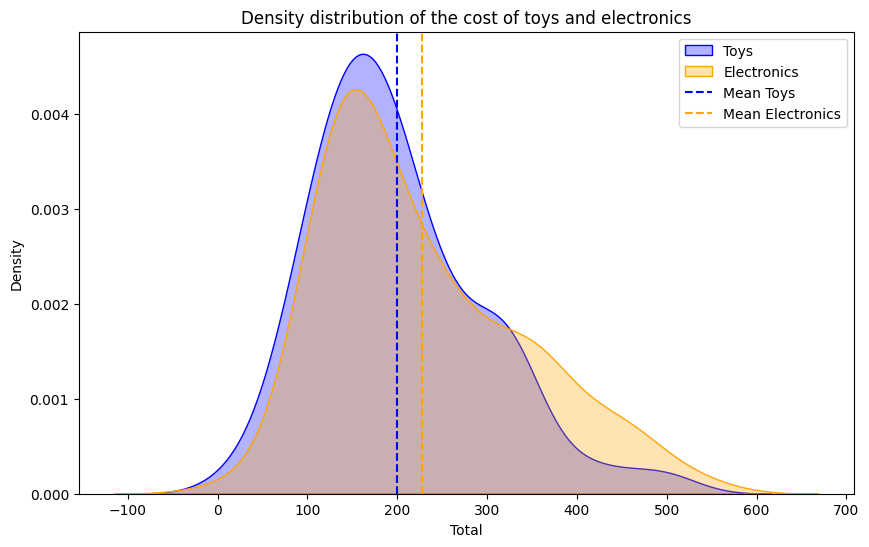

In [42]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    group_toys,
    label='Toys',
    fill=True,
    color='blue',
    alpha=0.3
)

sns.kdeplot(
    group_electronics,
    label='Electronics',
    fill=True,
    color='orange',
    alpha=0.3
)

plt.axvline(group_toys.mean(), color='blue', linestyle='--', label='Mean Toys')
plt.axvline(group_electronics.mean(), color='orange', linestyle='--', label='Mean Electronics')

plt.legend()
plt.title('Density distribution of the cost of toys and electronics')

**Вывод**:

с помощью проведенных тестов и графиков плотностей делаем вывод, что средний чек продаж Toys и Electronics примерно равен.

## 3.6. Однофакторный дисперсионный анализ

Сравним категорию посетителей с величиной чека.

In [32]:
groups = [group['Total'].values for name, group in clean_data.groupby('Customer.Category')]

f_stat, p_value = stats.f_oneway(*groups)

p_value.item()

1.780324417531675e-05

**Вывод**:

Получили значение p_value < 0.05, а значит среди групп покупателей действительно есть разница в величине чека.

Хоть Total распределено не нормально, мы можем применить дисперсионный анализ, так как в каждой группе большой объем данных.

# 4. Выводы и рекомендации

**Выводы**:

* женщины совершают меньше покупок, но их медианный чек больше
* в Екатеринбурге люди совершают больше всего покупок, но сумма чека меньше, чем в других городах. В Москве наоборот: покупок всего, а чек больше
* в основном участники программы лояльности совершают больше покупок
* в Москве и Санкт-Петербурге величина среднего чека больше при меньших затратах на рекламу


**Рекомендации**:

* разработать программу лояльности или спецпредложения для увелечения частоты покупоку у женской аудитории
* продолжать поддерживать участников программы лояльности
* в Москве и Санкт-Петербурге пересмотреть рекламынй бюджет и перераспределить его на привлечение новой аудитории

**Ключевой инсайт**:

Москва является стратегически важным регионом с максимально высокой маржинальностью на одного клиента, в то время как Екатеринбург требует работы над качеством корзины (увеличением ее стоимости).